In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hist_df=pd.read_csv("data.csv")
hist_df.head()

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


In [3]:
train_data=hist_df[-3000:]

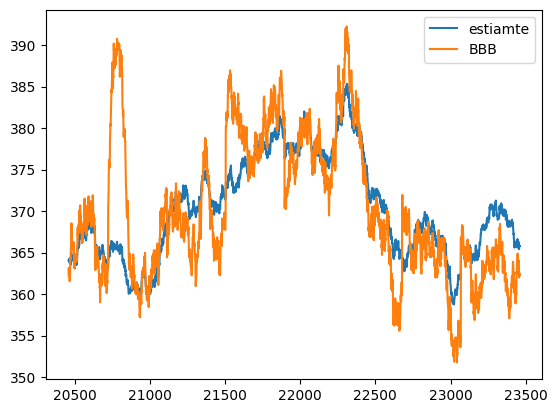

In [4]:
intercept,coef=95.46931822547003,1.05311287
sd=4.31792969543484

secutiry1="ETF"
secutiry2="BBB"

y_fit=train_data[secutiry1]*coef+intercept
plt.plot(y_fit, label="estiamte")
plt.plot(train_data[secutiry2],label=secutiry2)

plt.legend()

In [5]:
train_data.index
diff=train_data[secutiry2]-y_fit

In [11]:
diff=train_data[secutiry2]-y_fit
x=np.linspace(0.1,3,5)
y=np.linspace(0.1,2,5)
all=[]
mean=-1.0595512300584884

for buy_in in x:
    for back in y:
        start_capital=1000000
        total=start_capital
        tot_ETF=0
        tot_IND=0
        profit=[1]
        porto=total

        if(back>=buy_in):
            continue

        for i in train_data.index:
            if(i==20460): continue
            lasttot=porto

            #sell etf at high
            if(diff[i]>=mean+buy_in*sd and bought==0):
                amount_etf=total//2//train_data[secutiry2][i]
                amount_ind=total//2//train_data[secutiry1][i]

                tot_IND+=amount_ind
                tot_ETF-=amount_etf

                total+=abs(amount_etf*train_data[secutiry2][i])
                total-=abs(amount_ind*train_data[secutiry1][i])
                bought=1
                #print(tot_ETF,i,total)

            elif(diff[i]<=mean+back*sd and tot_ETF<0 and bought==1):
                total-=abs(tot_ETF*train_data[secutiry2][i])
                total+=abs(tot_IND*train_data[secutiry1][i])
                tot_ETF=0
                tot_IND=0
                bought=0
                #print(tot_ETF,i,total)

            #buy etf at low
            elif(diff[i]<=mean-buy_in*sd and bought==0):
                amount_etf=total//2//train_data[secutiry2][i]
                amount_ind=total//2//train_data[secutiry1][i]

                tot_IND-=amount_ind
                tot_ETF+=amount_etf

                total-=abs(amount_etf*train_data[secutiry2][i])
                total+=abs(amount_ind*train_data[secutiry1][i])
                bought=1
                #print(tot_ETF,i,total)

            #go back
            elif(diff[i]>=mean-back*sd and tot_ETF>0 and bought==1):
                total+=abs(tot_ETF*train_data[secutiry2][i])
                total-=abs(tot_IND*train_data[secutiry1][i])
                tot_ETF=0
                tot_IND=0
                bought=0
                #print(tot_ETF,i,total)

            porto=total+tot_ETF*train_data[secutiry2][i]+tot_IND*train_data[secutiry1][i]
            profit.append(porto/lasttot)


        bought=0

        total+=tot_ETF*train_data[secutiry2][i]
        total+=tot_IND*train_data[secutiry1][i]

        profit=pd.DataFrame(np.array(profit))

        Rp=total/start_capital

        Rf=(train_data["IND"][23459]/train_data["IND"][20460])
        Rf=max(Rf,1)
        #train_data["IND"]
        sigma=np.sqrt(profit[0].var())

        sharpe=(Rp-Rf)/sigma/3000*np.sqrt(391)
        all.append((sharpe,total,buy_in,back))
 



In [12]:
all.sort(reverse=True)

for i in range(5):
    print(all[i])

(np.float64(1.2612982923486882), np.float64(1163910.46), np.float64(0.825), np.float64(0.575))
(np.float64(1.2423418009450125), np.float64(1180397.6300000013), np.float64(0.825), np.float64(0.1))
(np.float64(1.0390754584888489), np.float64(1120946.3000000005), np.float64(1.55), np.float64(0.575))
(np.float64(0.9626898178191013), np.float64(1126260.0500000003), np.float64(1.55), np.float64(0.1))
(np.float64(0.6667045374309255), np.float64(1070536.940000001), np.float64(1.55), np.float64(1.05))
